In [23]:
import numpy as np
import time
import matplotlib.pyplot as plt



In [24]:
N = 10_000_000


python_list = list(range(N))

start = time.perf_counter()

for i in range(N):
    python_list[i] *= 2

python_time = time.perf_counter() - start
print(f"Python loop time : {python_time:.6f} sec")

Python loop time : 2.225689 sec


In [25]:
numpy_array = np.arange(N, dtype=np.int64)

start = time.perf_counter()

numpy_array *= 2

numpy_time = time.perf_counter() - start
print(f"NumPy time       : {numpy_time:.6f} sec")

NumPy time       : 0.015715 sec


In [26]:
print(f"Speedup          : {python_time/numpy_time:.2f}x")

Speedup          : 141.63x



Latency per element
Python : 222.57 ns
NumPy  : 1.57 ns


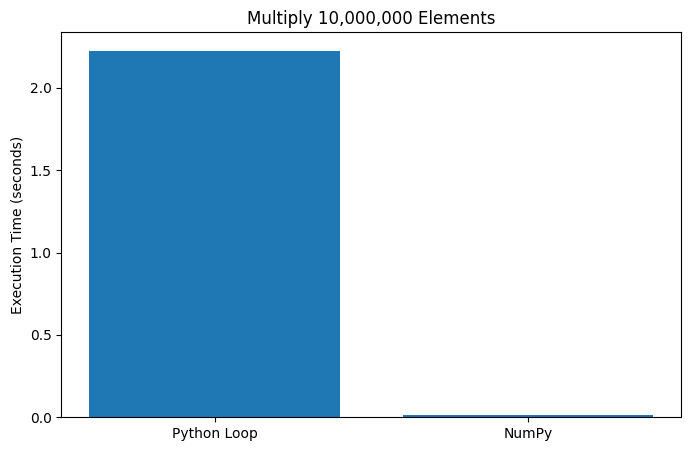

In [27]:
# Latency per element
python_latency_ns = python_time / N * 1e9
numpy_latency_ns = numpy_time / N * 1e9

print(f"\nLatency per element")
print(f"Python : {python_latency_ns:.2f} ns")
print(f"NumPy  : {numpy_latency_ns:.2f} ns")

# ----------------------------
# Visualization
# ----------------------------
methods = ["Python Loop", "NumPy"]
times = [python_time, numpy_time]

plt.figure(figsize=(8,5))
plt.bar(methods, times)
plt.ylabel("Execution Time (seconds)")
plt.title(f"Multiply {N:,} Elements")
plt.show()

In [28]:
import sys

x = 5

print(type(x))
print(sys.getsizeof(x))
print(id(x))

<class 'int'>
28
11645480


In [29]:
  import sys

arr = [1,2,3,4,5]

print(type(arr))
print(sys.getsizeof(arr))

for x in arr:
    print(type(x), sys.getsizeof(x))

<class 'list'>
104
<class 'int'> 28
<class 'int'> 28
<class 'int'> 28
<class 'int'> 28
<class 'int'> 28


In [30]:
import numpy as np

arr = np.array([1,2,3,4,5], dtype=np.int64)

print(type(arr))
print(arr.dtype)
print(arr.nbytes)
print(arr.itemsize)

<class 'numpy.ndarray'>
int64
40
8


In [31]:
arr = [1,2,3,4,5]

for x in arr:
    print(id(x))

11645352
11645384
11645416
11645448
11645480


In [32]:
import numpy as np

arr = np.array([1,2,3,4,5], dtype=np.int64)

print(arr.ctypes.data)

1046361008


In [33]:
for i in range(len(arr)):
    print(arr.ctypes.data + i * arr.itemsize)

1046361008
1046361016
1046361024
1046361032
1046361040


In [34]:
import numpy as np
import sys

N = 1_000_000

python_list = list(range(N))
numpy_array = np.arange(N, dtype=np.int64)

python_memory = (
    sys.getsizeof(python_list)
    + sum(sys.getsizeof(x) for x in python_list)
)

numpy_memory = numpy_array.nbytes

print(f"Python List : {python_memory/1024/1024:.2f} MB")
print(f"NumPy Array : {numpy_memory/1024/1024:.2f} MB")

Python List : 34.33 MB
NumPy Array : 7.63 MB


In [35]:
import numpy as np

arr = np.array([1,2,3], dtype=np.int64)

print(arr.tobytes())

b'\x01\x00\x00\x00\x00\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00\x00\x03\x00\x00\x00\x00\x00\x00\x00'


In [36]:
import numpy as np

python_list = [1,2,3,4,5]
numpy_array = np.array([1,2,3,4,5], dtype=np.int64)

print("Python list element addresses:")
for x in python_list:
    print(id(x))

print("\nNumPy element addresses:")
base = numpy_array.ctypes.data

for i in range(len(numpy_array)):
    print(base + i * numpy_array.itemsize)

Python list element addresses:
11645352
11645384
11645416
11645448
11645480

NumPy element addresses:
1046361008
1046361016
1046361024
1046361032
1046361040


In [37]:
import numpy as np
import time

sizes = [
    1_000,
    10_000,
    100_000,
    1_000_000,
    10_000_000,
    50_000_000
]

for n in sizes:
    arr = np.arange(n, dtype=np.int64)

    start = time.perf_counter()
    arr *= 2
    elapsed = time.perf_counter() - start

    print(
        f"{n:>10,d} elements : "
        f"{elapsed:.6f} sec"
    )

     1,000 elements : 0.000027 sec
    10,000 elements : 0.000021 sec
   100,000 elements : 0.000134 sec
 1,000,000 elements : 0.001468 sec
10,000,000 elements : 0.015541 sec
50,000,000 elements : 0.081023 sec


In [38]:
N = 4000

# Create a large contiguous matrix
matrix = np.ones((N, N), dtype=np.float64)

# -------------------------
# Row-major traversal
# -------------------------
start = time.perf_counter()

total = 0.0
for i in range(N):
    for j in range(N):
        total += matrix[i, j]

row_time = time.perf_counter() - start

print(f"Row-major time: {row_time:.3f} sec")
print("Shape of the matrix :", matrix.shape)


Row-major time: 5.547 sec
Shape of the matrix : (4000, 4000)


In [39]:
# -------------------------
# Column-major traversal
# -------------------------
start = time.perf_counter()

total = 0.0
for j in range(N):
    for i in range(N):
        total += matrix[i, j]

col_time = time.perf_counter() - start

print(f"Column-major time: {col_time:.3f} sec")

print(f"Column/Row ratio: {col_time / row_time:.2f}x")

Column-major time: 6.801 sec
Column/Row ratio: 1.23x


In [51]:
import ctypes

numbers = [10, 20, 30]

for i in range(len(numbers)):
    addr = id(numbers[i])

    obj = ctypes.cast(addr, ctypes.py_object).value

    print(f"Address: {hex(addr)}")
    print(f"Object : {obj}")
    print(f"Type   : {type(obj)}")
    print()

Address: 0xb1b2c8
Object : 10
Type   : <class 'int'>

Address: 0xb1b408
Object : 20
Type   : <class 'int'>

Address: 0xb1b548
Object : 30
Type   : <class 'int'>



In [41]:
import sys

numbers = [10, 20, 30]

print("List size:", sys.getsizeof(numbers), "bytes")

List size: 88 bytes


In [42]:
numbers = [10, 20, 30]

for i in range(len(numbers)):
    print(f"numbers[{i}] points to {hex(id(numbers[i]))}")

numbers[0] points to 0xb1b2c8
numbers[1] points to 0xb1b408
numbers[2] points to 0xb1b548


In [49]:
arr = np.array([10,20,30])
arr.size

3

In [55]:
import random
import time

N = 10_000_000

data = list(range(N))

# Sequential access
start = time.perf_counter()

s = 0
for i in range(N):
    s += data[i]

end = time.perf_counter()

print(f"Sequential: {end-start:.3f} sec")




Sequential: 2.745 sec


In [56]:
import random
import time

N = 10_000_000
data = list(range(N))

# Random access
indices = list(range(N))
random.shuffle(indices)

start = time.perf_counter()

s = 0
for i in indices:
    s += data[i]

end = time.perf_counter()

print(f"Random: {end-start:.3f} sec")

Random: 10.119 sec


In [57]:
import numpy as np
import time

N = 10_000_000

data = np.arange(N, dtype=np.int64)

# Sequential memory access
start = time.perf_counter()

s = data.sum()

end = time.perf_counter()

print(f"Sequential NumPy: {end-start:.3f} sec")



Sequential NumPy: 0.008 sec


In [59]:
import numpy as np
import time

N = 10_000_000

# Random memory access
indices = np.random.permutation(N)

start = time.perf_counter()

s = data[indices].sum()

end = time.perf_counter()

print(f"Random NumPy: {end-start:.3f} sec")

Random NumPy: 0.190 sec


In [60]:
import numpy as np
import time

N = 100_000_000

data = np.arange(N, dtype=np.int64)

# Contiguous access
start = time.perf_counter()
data.sum()
end = time.perf_counter()

print("Contiguous:", end - start)

# Strided access
start = time.perf_counter()
data[::1024].sum()
end = time.perf_counter()

print("Stride 1024:", end - start)

Contiguous: 0.0763573299991549
Stride 1024: 0.0014789969991397811
